In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from scipy.stats import skew, kurtosis, levy_stable
import powerlaw
import pyarrow.parquet as pq

def pl_fit(data):
    """
    Calculate exponent of powerlaw and standard deviation of parameter uncertainty for alpha
    """
    result = powerlaw.Fit(data).power_law
    alpha = result.alpha
    sigma = result.sigma

    return alpha, sigma

def calc_moments(data):
    """
    Returns the 0th-3rd moments of a 1D dataset.
    """
    totalprob = 1

    mean = np.mean(data)
    variance = np.var(data,ddof=1) + mean**2 #ddof=1 for sample variance
    skewness = skew(data)
    return [totalprob, mean, variance, skewness]

def crit_params(data):
    """
    Fit data to Levy stable distribution and output alpha and beta estimates.
    """

    alpha_est, beta_est, loc_est, scale_est = levy_stable.fit(data)
    return alpha_est, beta_est

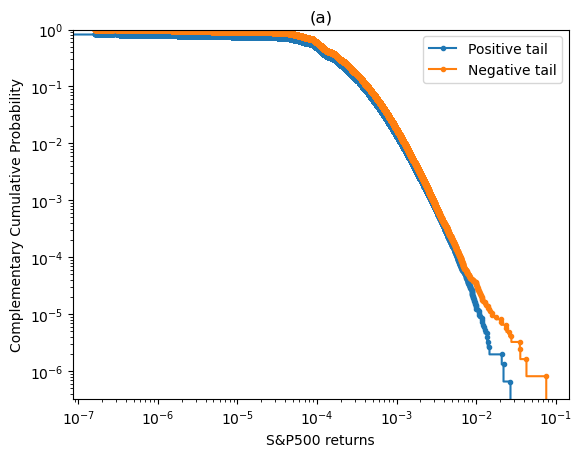

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 1526954, 1232069
3.7808795234728865+-0.03340049454403815, 3.9177492763654196+-0.0506230323339922


In [ ]:
# Plot 1-min S&P500 stock price return CCDF

# Set inputs
files = ['Datasets\DAT_ASCII_SPXUSD_M1_2016.csv','Datasets\DAT_ASCII_SPXUSD_M1_2017.csv','Datasets\DAT_ASCII_SPXUSD_M1_2018.csv',
         'Datasets\DAT_ASCII_SPXUSD_M1_2019.csv','Datasets\DAT_ASCII_SPXUSD_M1_2020.csv','Datasets\DAT_ASCII_SPXUSD_M1_2021.csv',
         'Datasets\DAT_ASCII_SPXUSD_M1_2022.csv','Datasets\DAT_ASCII_SPXUSD_M1_2023.csv','Datasets\DAT_ASCII_SPXUSD_M1_2024.csv']
plottitle = '(a)'
xaxislabel = 'S&P500 returns'

gains, filteredgains, losses, filteredlosses = [], [], [], []

for i,filename in enumerate(files):
            
    # Extract prices for calculation of returns
    df = pd.read_csv(filename, header=None, sep=';')
    prices = df.iloc[:,4].to_numpy() # Extract 4th column 'Bar CLOSE Bid Quote'

    # Find the 'return' r. Separate r values into gains and losses.
    for j,price in enumerate(prices):
        if j < len(prices)-1:
            r=math.log(prices[j+1]) - math.log(price)
            if r>=0:
                gains.append(r)
                if r>=5E-4: # Cutoff point at which power-law tail starts is determined visually from the log-log plot of the CCDF of returns
                    filteredgains.append(r)
            else:
                losses.append(abs(r))
                if r<=-5E-4:
                    filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title(plottitle)
plt.xlabel(xaxislabel)
plt.ylabel('Complementary Cumulative Probability')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

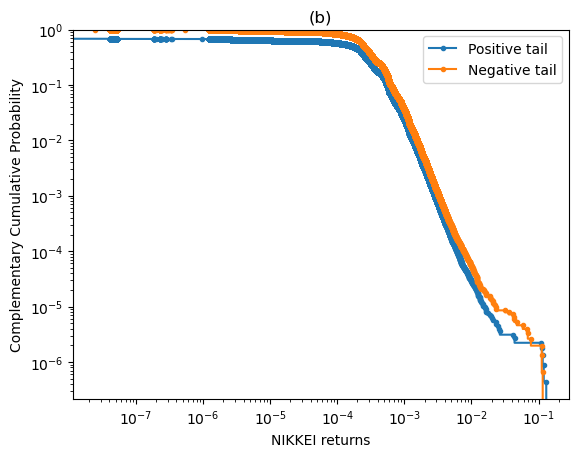

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 2246546, 1517898
4.063673497475552+-0.023502833827531468, 4.022986670441163+-0.022873207619833313


In [ ]:
# Plot 1-min NIKKEI stock price return CCDF

# Set inputs
files = ['Datasets\DAT_ASCII_JPXJPY_M1_2010.csv','Datasets\DAT_ASCII_JPXJPY_M1_2011.csv','Datasets\DAT_ASCII_JPXJPY_M1_2012.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2013.csv','Datasets\DAT_ASCII_JPXJPY_M1_2014.csv','Datasets\DAT_ASCII_JPXJPY_M1_2015.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2016.csv','Datasets\DAT_ASCII_JPXJPY_M1_2017.csv','Datasets\DAT_ASCII_JPXJPY_M1_2018.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2019.csv','Datasets\DAT_ASCII_JPXJPY_M1_2020.csv','Datasets\DAT_ASCII_JPXJPY_M1_2021.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2022.csv','Datasets\DAT_ASCII_JPXJPY_M1_2023.csv','Datasets\DAT_ASCII_JPXJPY_M1_2024.csv']
plottitle = '(b)'
xaxislabel = 'NIKKEI returns'

gains = []
losses = []
filteredgains = []
filteredlosses = []

for i,filename in enumerate(files):
            
    # Obtain normalized data
    df = pd.read_csv(filename, header=None, sep=';') 
    prices = df.iloc[:,4].to_numpy() # Extract 4th column 'Bar CLOSE Bid Quote'

    # Find the 'return' r. Separate r values into gains and losses.
    for j,price in enumerate(prices):
        if j < len(prices)-1:
            r=math.log(prices[j+1]) - math.log(price)
            if r>=0:
                gains.append(r)
                if r>=5E-4:
                    filteredgains.append(r)
            else:
                losses.append(abs(r))
                if r<-5E-4:
                    filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title(plottitle)
plt.xlabel(xaxislabel)
plt.ylabel('Complementary Cumulative Probability')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

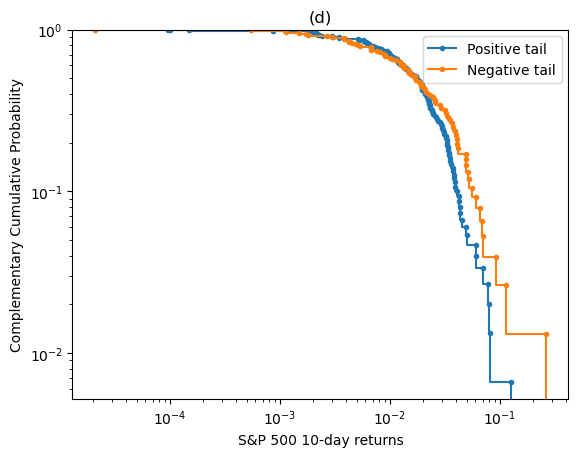

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 150, 76
3.9897875728933596+-0.5053663375930535, 3.4095020612723514+-0.7264922062571196


In [ ]:
# Change frequency of data by changing day_interval from 1 onwards

# Set inputs
sourcefile = 'Datasets\SP500_2016-2024_daily.csv'
day_interval = 10 # Take data every day_interval days
plottitle = '(d)'
xaxislabel = f'S&P 500 {day_interval}-day returns'

df = pd.read_csv(sourcefile)
extracted_arr = df.iloc[::day_interval,1].to_numpy() # Extract 1st column 'Close/Last' data at every day_interval days
prices = extracted_arr[~(np.isnan(extracted_arr))]

gains = []
losses = []
filteredgains = []
filteredlosses = []

# Find the 'return' r. Separate r values into gains and losses.
for j,price in enumerate(prices):
    if j < len(prices)-1:
        r=math.log(prices[j+1]) - math.log(price)
        if r>=0:
            gains.append(r)
            if r>=1E-2:
                filteredgains.append(r)
        else:
            losses.append(abs(r))
            if r<=-1E-2:
                filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title(plottitle)
plt.xlabel(xaxislabel)
plt.ylabel('Complementary Cumulative Probability')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

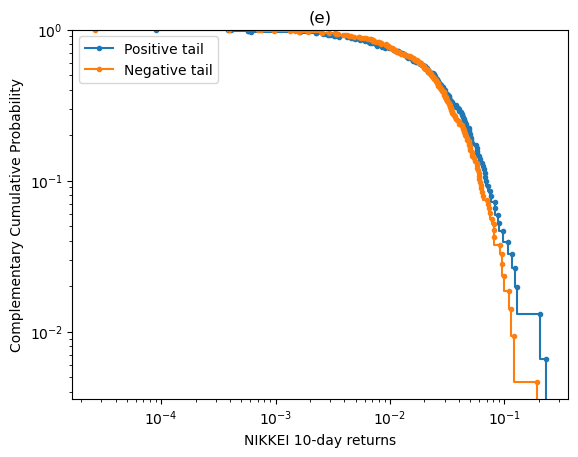

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 152, 214
3.6157337124730535+-0.5231467424946107, 4.359569686026366+-0.6348989929583652


In [ ]:
# Change frequency of data by changing day_interval from 1 onwards

# Set inputs
sourcefile = r'Datasets\Nikkei225_2010-2024 daily.csv'
day_interval = 10 # Take data every day_interval days
plottitle = '(e)'
xaxislabel = f'NIKKEI {day_interval}-day returns'

df = pd.read_csv(sourcefile)
extracted_arr = df.iloc[::day_interval,1].to_numpy() # Extract 1st column 'Price' data at every day_interval days
prices = extracted_arr[~(np.isnan(extracted_arr))]

gains = []
losses = []
filteredgains = []
filteredlosses = []

# Find the 'return' r. Separate r values into gains and losses.
for j,price in enumerate(prices):
    if j < len(prices)-1:
        r=math.log(prices[j+1]) - math.log(price)
        if r>=0:
            gains.append(r)
            if r>=1E-2:
                filteredgains.append(r)
        else:
            losses.append(abs(r))
            if r<=-1E-2:
                filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title(plottitle)
plt.xlabel(xaxislabel)
plt.ylabel('Complementary Cumulative Probability')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

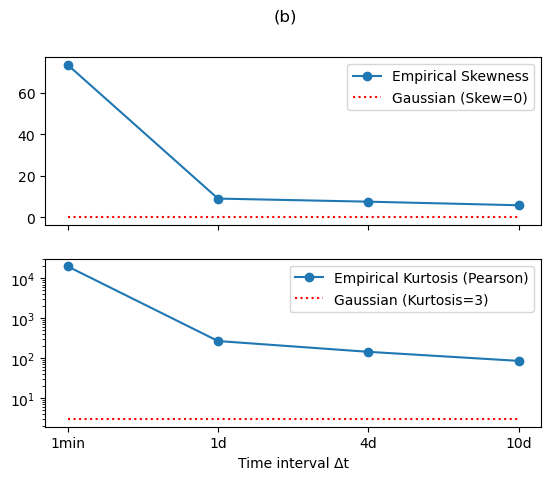

In [ ]:
# Plot 3rd and 4th moments of various choices of measurement interval, compare to Gaussian distribution. 
# Choose to analyze S&P 500 or NIKKEI by uncommenting the financial index of interest.

# S&P 500 files
#sourcefile = 'Datasets\SP500_2016-2024_daily.csv'
#files = ['Datasets\DAT_ASCII_SPXUSD_M1_2016.csv','Datasets\DAT_ASCII_SPXUSD_M1_2017.csv',
#         'Datasets\DAT_ASCII_SPXUSD_M1_2018.csv','Datasets\DAT_ASCII_SPXUSD_M1_2019.csv',
#         'Datasets\DAT_ASCII_SPXUSD_M1_2020.csv','Datasets\DAT_ASCII_SPXUSD_M1_2021.csv',
#         'Datasets\DAT_ASCII_SPXUSD_M1_2022.csv','Datasets\DAT_ASCII_SPXUSD_M1_2023.csv',
#         'Datasets\DAT_ASCII_SPXUSD_M1_2024.csv']

# NIKKEI files
sourcefile = r'Datasets\Nikkei225_2010-2024 daily.csv'
files = ['Datasets\DAT_ASCII_JPXJPY_M1_2010.csv','Datasets\DAT_ASCII_JPXJPY_M1_2011.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2012.csv','Datasets\DAT_ASCII_JPXJPY_M1_2013.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2014.csv','Datasets\DAT_ASCII_JPXJPY_M1_2015.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2016.csv','Datasets\DAT_ASCII_JPXJPY_M1_2017.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2018.csv','Datasets\DAT_ASCII_JPXJPY_M1_2019.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2020.csv','Datasets\DAT_ASCII_JPXJPY_M1_2021.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2022.csv','Datasets\DAT_ASCII_JPXJPY_M1_2023.csv',
         'Datasets\DAT_ASCII_JPXJPY_M1_2024.csv']

df = pd.read_csv(sourcefile)
fig, axs = plt.subplots(2)

# Create empty lists to store the returns of each day_interval
r=[]
r_1=[]
r_2=[]
r_3=[]

# Input the no. of days between each price in the data
day_interval_1=1
day_interval_2=4
day_interval_3=10

# Calculate the 1-min returns r
for i,filename in enumerate(files):

    df = pd.read_csv(filename, header=None, sep=';')
    prices = df.iloc[:,4].to_numpy() # Extract 4th column 'Bar CLOSE Bid Quote'

    for j,price in enumerate(prices):
        if j < len(prices)-1:
            r.append(abs(math.log(prices[j+1]) - math.log(price)))

# Extract 1st column 'Close/Last' data at every day_interval_1 days, remove any blank data.
extracted_arr_1 = df.iloc[::day_interval_1,1].to_numpy() 
prices_1 = extracted_arr_1[~(np.isnan(extracted_arr_1))]
extracted_arr_2 = df.iloc[::day_interval_2,1].to_numpy() 
prices_2 = extracted_arr_2[~(np.isnan(extracted_arr_2))]
extracted_arr_3 = df.iloc[::day_interval_3,1].to_numpy() 
prices_3 = extracted_arr_3[~(np.isnan(extracted_arr_3))]

# Calculate the multiple-day returns r_1, r_2, and r_3 from the price data
for j,price_1 in enumerate(prices_1):
    if j < len(prices_1)-1:
        r_1.append(abs(math.log(prices_1[j+1]) - math.log(price_1)))

for j,price_2 in enumerate(prices_2):
    if j < len(prices_2)-1:
        r_2.append(abs(math.log(prices_2[j+1]) - math.log(price_2)))

for j,price_3 in enumerate(prices_3):
    if j < len(prices_3)-1:
        r_3.append(abs(math.log(prices_3[j+1]) - math.log(price_3)))

# Plot skewness
t_intervals = ['1min', f'{day_interval_1}d', f'{day_interval_2}d', f'{day_interval_3}d']
momentvals = [skew(r), skew(r_1), skew(r_2), skew(r_3)]
axs[0].plot(t_intervals, momentvals, 'o-', label='Empirical Skewness')
axs[0].plot(t_intervals, [0,0,0,0], 'r', linestyle='dotted', label='Gaussian (Skew=0)')
axs[0].set_xticklabels([])
axs[0].legend()

# Plot kurtosis
t_intervals = ['1min', f'{day_interval_1}d', f'{day_interval_2}d', f'{day_interval_3}d']
momentvals = [kurtosis(r), kurtosis(r_1), kurtosis(r_2), kurtosis(r_3)]
axs[1].plot(t_intervals, momentvals, 'o-', label='Empirical Kurtosis (Pearson)')
axs[1].plot(t_intervals, [3,3,3,3], 'r', linestyle='dotted', label='Gaussian (Kurtosis=3)')
axs[1].set_xlabel('Time interval \u0394t')
axs[1].set_yscale('log')
axs[1].legend()
plt.suptitle('(b)')
plt.show()

In [ ]:
# Estimate Levy stable parameters for daily data

# Set inputs
sourcefile = 'Datasets\SP500_2016-2024_daily.csv' # Uncomment if you want to analyze S&P 500 returns
#sourcefile = r'Datasets\Nikkei225_2010-2024 daily.csv' # Uncomment if you want to analyze NIKKEI returns
window = 250 # Number of latest consecutive days to use in estimation of Levy stable parameters
cutoff = 1E-3 # Cutoff point at which the power-law tail starts was selected visually from the log-log plot of CCDF of returns

# Extract price data
df = pd.read_csv(sourcefile)
prices = df.iloc[:,1].tail(window).to_numpy() # Extract 1st column 'Close/Last' data of the latest dates
dates = df.iloc[:,0].tail(window).tolist()

filteredreturns = []

# Find the 'return' r
for j,price in enumerate(prices):
    if j < len(prices)-1:
        r=math.log(prices[j+1]) - math.log(price)

        if r>=cutoff or r<=-cutoff:
            filteredreturns.append(r)

print(f'no. of filtered returns = {len(filteredreturns)}')
print(f'time period of window: {dates[0]} to {dates[len(dates)-1]}')
print(f'alpha, beta = {crit_params(filteredreturns)}')

no. of filtered returns = 216
time period of window: 01 04 2024 to 12/31/2024
alpha, beta = (np.float64(1.8108501880587036), np.float64(-0.7825145533601245))


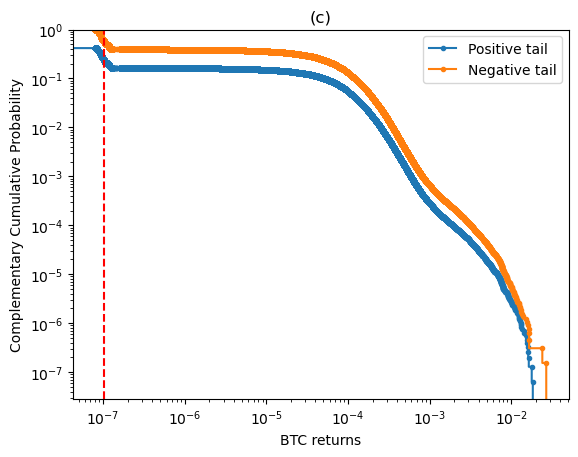

Calculating best minimal value for power law fit


In [ ]:
# Plot log-log plot of Bitcoin returns CCDF. Fit to power-law and calculate alpha.

# Set inputs
sourcefile = r'Datasets\bars_1s.parquet'
interval = '1s'
plottitle = '(c)'
xaxislabel = f'BTC returns'
cutoff_q = 75 # Cutoff point at which the power-law tail starts

# Convert the Parquet file to a pandas dataframe
parquet_file = pq.ParquetFile(sourcefile)
df = parquet_file.read().to_pandas()

# Extract prices from the dataframe
extracted_arr = df.iloc[:,1].to_numpy() # Extract 1st column 'Close/Last' data at every day_interval days
prices = extracted_arr[~(np.isnan(extracted_arr))]

gains = []
losses = []
filteredgains = []
filteredlosses = []

# Find the 'return' r. Separate r values into gains and losses.
for j,price in enumerate(prices):
    if j < len(prices)-1:
        r=math.log(prices[j+1]) - math.log(price)

        if r>=0:
            gains.append(r)
        
        else:
            losses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

# Calculate the cutoff return at which the power-law tail starts
cutoff_returns = np.percentile(np.array(gains), cutoff_q)
plt.axvline(x=cutoff_returns, color='r', linestyle='--')

#plt.title(plottitle)
plt.xlabel(xaxislabel)
plt.ylabel('Complementary Cumulative Probability')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper right')
plt.show()

for k,gain in enumerate(gains):
    if gain >= cutoff_returns:
        filteredgains.append(gain)

for k,loss in enumerate(losses):
    if loss >= cutoff_returns:
        filteredlosses.append(loss)

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')